# Spoiler Detection on IMDB movie reviews

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


## IMDB Spoiler Dataset

source: https://www.kaggle.com/datasets/rmisra/imdb-spoiler-dataset

### Importing and Inspecting Raw Data

In [2]:
from pathlib import Path


In [3]:
ROOT = Path.cwd().resolve().parent
DATA_DIR = ROOT / 'data'
REVIEW_PATH = DATA_DIR / 'IMDB_reviews.json'
MOVIE_PATH = DATA_DIR / 'IMDB_movie_details.json'
CSV_PATH = DATA_DIR / 'preprocessed_reviews.csv'

# raw text
if CSV_PATH.exists():
    review_data = pd.read_csv(CSV_PATH, encoding='utf-8')
else:
    review_data = pd.read_json(REVIEW_PATH, lines=True)
review_data.head(3)


,review_date,movie_id,user_id,is_spoiler,review_text,rating,review_summary,word_count,cleaned_text,processed_text,final_text
0,10 February 2006,tt0111161,ur1898687,True,"In its Oscar year, Shawshank Redemption (writt...",10,A classic piece of unforgettable film-making.,843,in its oscar year shawshank redemption written...,in it oscar year shawshank redemption write an...,oscar year shawshank redemption write direct f...
1,6 September 2000,tt0111161,ur0842118,True,The Shawshank Redemption is without a doubt on...,10,Simply amazing. The best film of the 90's.,223,the shawshank redemption is without a doubt on...,the shawshank redemption be without a doubt on...,shawshank redemption without doubt one brillia...
2,3 August 2001,tt0111161,ur1285640,True,I believe that this film is the best story eve...,8,The best story ever told on film,250,i believe that this film is the best story eve...,i believe that this film be the best story eve...,believe film best story ever tell film im tell...


In [4]:
movie_data = pd.read_json(MOVIE_PATH, lines=True)
movie_data.head(3)


,movie_id,plot_summary,duration,genre,rating,release_date,plot_synopsis
0,tt0105112,"Former CIA analyst, Jack Ryan is in England wi...",1h 57min,"[Action, Thriller]",6.9,1992-06-05,"Jack Ryan (Ford) is on a ""working vacation"" in..."
1,tt1204975,"Billy (Michael Douglas), Paddy (Robert De Niro...",1h 45min,[Comedy],6.6,2013-11-01,Four boys around the age of 10 are friends in ...
2,tt0243655,"The setting is Camp Firewood, the year 1981. I...",1h 37min,"[Comedy, Romance]",6.7,2002-04-11,


In [5]:
# see the sample of spoiler reviews & non-spoiler reviews
review_data['word_count']=review_data['review_text'].apply(lambda x:len(x.split()))

spoiler_samples = review_data[(review_data['is_spoiler'] == 1) & (review_data['word_count'] < 70)].head(2)
non_spoiler_samples = review_data[(review_data['is_spoiler'] == 0) & (review_data['word_count'] < 70)].head(2)

samples = pd.concat([spoiler_samples, non_spoiler_samples])

with pd.option_context('display.max_colwidth', None):
    display(samples[['review_text', 'is_spoiler', 'word_count']])


,review_text,is_spoiler,word_count
75,"This movie will be one of my favorite's of all time, it's heartwarming, sad, funny at times and won't let you down. justice is served! Morgan Freeman plays the supporting character for Tim Robbins and just made the movie. He creates so much emotion to this film as the narrator and supporting character to the storyline it just leaves you in total awe of his talent.",True,66
78,"Excellent movie, I have watched it twice no thrice :) very thrilling :). The characters fulfilled their roles very good. The graphics was astonishing in my eyes. If you want to enjoy these movie watch this in HD format. It was very memorable to watch such kind of movie. The shawshank redemption is included in my top ten favorite to watch. I will give it an excellent score.",True,68
993,"This is definitely one of my favorite movies -- it makes me cry and laugh and ache inside all at once. Tim Robbins, you make my days a little brighter -- thank you!",False,33
1003,Shawshank Redemption is without a doubt the most uplifting and touching film I have ever seen. It is the only movie I've seen that has made tears of happiness come to my eyes. I would (and do) recommend this film to anyone and everyone.,False,44


### Data Exploration (EDA)

In [6]:
review_data.shape, movie_data.shape


((573913, 11), (1572, 7))

In [7]:
review_data['is_spoiler'].value_counts()


is_spoiler
False    422989
True     150924
Name: count, dtype: int64

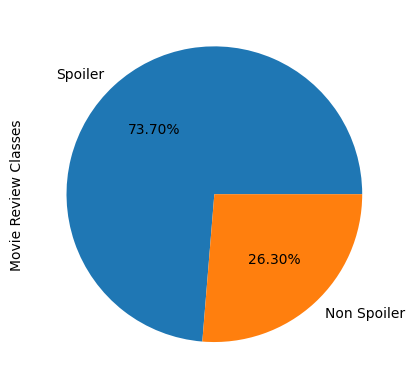

In [8]:
plt.pie(review_data['is_spoiler'].value_counts(), labels=['Spoiler','Non Spoiler'],autopct='%.2f%%')
plt.ylabel('Movie Review Classes');


<Axes: xlabel='word_count', ylabel='Count'>

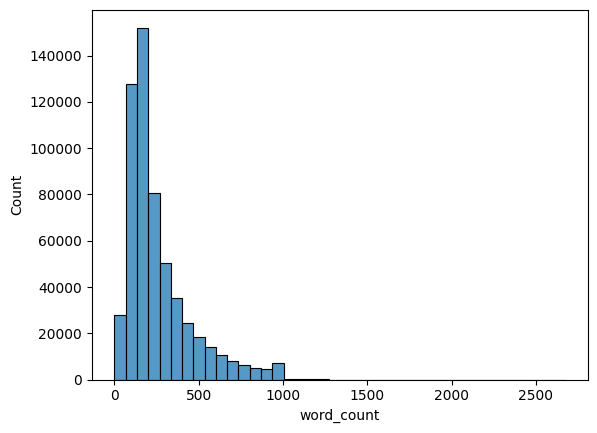

In [9]:
# How many words per review
sns.histplot(x=review_data['word_count'], bins=40)


## Data Preprocessing NLTK


### Standardising data to lower case & punctuation removal

In [10]:
# Standardising data to lower case & punctuation removal
import re

def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    return text

# Apply cleaning to the text column
review_data['cleaned_text'] = review_data['review_text'].apply(clean_text)


In [11]:
# sample review
review_data['cleaned_text'].iloc[2]


'i believe that this film is the best story ever told on film and im about to tell you whytim robbins plays andy dufresne a city banker wrongfully convicted of murdering his wife and her lover he is sent to shawshank prison in 1947 and receives a double life sentence for the crime andy forms an unlikely friendship with red morgan freeman the man who knows how to get things andy faces many trials in prison but forms an alliance with the wardens because he is able to use his banking experience to help the corrupt officials amass personal fortunes the story unfoldsi was so impressed with how every single subplot was given a great deal of respect and attention from the director the acting was worldclass i have never seen tim robbins act as well since morgan freeman maybe eg seven the twists were unexpected an although this film had a familiar feel it wasnt even slightly pretentious or cliched it was original the cinematography was grand and expressive it gave a real impression of the sheer

### Tokinaizing & Lemmatizing data

In [12]:
# Tokinaizing & Lemmatizing data
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK data files
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package punkt to /home/glimzzc/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/glimzzc/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /home/glimzzc/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/glimzzc/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/glimzzc/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/glimzzc/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [13]:
from nltk import pos_tag
from nltk.corpus import wordnet

# Function to get the wordnet POS tag
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN


In [14]:
def tokenize_and_lemmatize(text):
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)
    lemmatized_tokens = [lemmatizer.lemmatize(token, get_wordnet_pos(pos)) for token, pos in pos_tags]
    return ' '.join(lemmatized_tokens)

# Apply tokenization and lemmatization
if not CSV_PATH.exists():
    review_data['processed_text'] = review_data['cleaned_text'].apply(tokenize_and_lemmatize)


In [15]:
# Display the first few rows of the processed data
review_data[['review_text', 'processed_text']].head()


,review_text,processed_text
0,"In its Oscar year, Shawshank Redemption (writt...",in it oscar year shawshank redemption write an...
1,The Shawshank Redemption is without a doubt on...,the shawshank redemption be without a doubt on...
2,I believe that this film is the best story eve...,i believe that this film be the best story eve...
3,"**Yes, there are SPOILERS here**This film has ...",yes there be spoiler herethis film have have s...
4,At the heart of this extraordinary movie is a ...,at the heart of this extraordinary movie be a ...


### Dealing with stop words

In [16]:
# Dealing with stop words
from nltk.corpus import stopwords

# Download stopwords list
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/glimzzc/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
# Dealing with stop words
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered_tokens = [token for token in tokens if token not in stop_words]
    return ' '.join(filtered_tokens)

# Remove stop words
if not CSV_PATH.exists():
    review_data['final_text'] = review_data['processed_text'].apply(remove_stopwords)


In [18]:
# Display the first few rows of the final processed data
review_data[['review_text', 'final_text']].head()


,review_text,final_text
0,"In its Oscar year, Shawshank Redemption (writt...",oscar year shawshank redemption write direct f...
1,The Shawshank Redemption is without a doubt on...,shawshank redemption without doubt one brillia...
2,I believe that this film is the best story eve...,believe film best story ever tell film im tell...
3,"**Yes, there are SPOILERS here**This film has ...",yes spoiler herethis film emotional impact fin...
4,At the heart of this extraordinary movie is a ...,heart extraordinary movie brilliant indelible ...


In [19]:
# Save preprocessed data
if not CSV_PATH.exists():
    review_data.to_csv(CSV_PATH , index=False, encoding='utf-8')


## Feature Extraction

### TF-IDF

In [20]:
# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the text data
tfidf_matrix = vectorizer.fit_transform(review_data['final_text'])

# Display the shape of the TF-IDF matrix
tfidf_matrix.shape


(573913, 5000)

## Train-test split

We split the TF-IDF matrix by `movie_id` so reviews from the same film stay in the same partition.
This avoids leakage from similar plot-related wording across train and test.


In [21]:
from sklearn.model_selection import GroupShuffleSplit

X = tfidf_matrix
y = review_data['is_spoiler']
groups = review_data['movie_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss.split(X, y, groups))

X_train_val = X[train_val_idx]
y_train_val = y.iloc[train_val_idx].reset_index(drop=True)
groups_train_val = review_data.iloc[train_val_idx]['movie_id'].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=42)
train_idx, val_idx = next(gss2.split(X_train_val, y_train_val, groups_train_val))

X_train = X_train_val[train_idx]
X_val = X_train_val[val_idx]
X_test = X[test_idx]

y_train = y_train_val.iloc[train_idx].reset_index(drop=True)
y_val = y_train_val.iloc[val_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)

X_train.shape, X_val.shape, X_test.shape


((412358, 5000), (82825, 5000), (78730, 5000))

## Models Development

We now train and compare Logistic Regression and Naive Bayes on the movie-level split.
Validation is used for model selection, and the test set is kept for the final report.


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import torch


In [23]:
# move data to GPU
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(device)

# X_train = torch.tensor(X_train.toarray(), dtype=torch.float32).to(device)
# X_val   = torch.tensor(X_val.toarray(),   dtype=torch.float32).to(device)
# X_test  = torch.tensor(X_test.toarray(),  dtype=torch.float32).to(device)

# y_train = torch.tensor(y_train.values, dtype=torch.long).to(device)
# y_val   = torch.tensor(y_val.values,   dtype=torch.long).to(device)
# y_test  = torch.tensor(y_test.values,  dtype=torch.long).to(device)

### Exploring parameters and training models for increased accuracy


#### 1) Logistic Regression


In [24]:
# Define the parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

# Initialize the model
LR = LogisticRegression(max_iter=1000)

# Perform grid search
grid_search = GridSearchCV(LR, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Score:", grid_search.best_score_)

# Identifying best model
best_lr = grid_search.best_estimator_

# Validate the model
y_val_pred_best = best_lr.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_best))

# Predict on the test data
y_pred_best_lr = best_lr.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred_best_lr))


Best Parameters: {'C': 0.1, 'solver': 'saga'}
Best Cross-validation Score: 0.7540777819590087
Validation Accuracy: 0.776963477210987
Test Accuracy: 0.7795249587196749


#### 2) MultinomialNB (Naive Bayes)


In [25]:
# Define the parameter grid
param_grid_nb = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

# Initialize the model
NB = MultinomialNB()

# Perform grid search
grid_search_nb = GridSearchCV(NB, param_grid_nb, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_nb.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search_nb.best_params_)
print("Best Cross-validation Score:", grid_search_nb.best_score_)

# Identifying best model
best_nb = grid_search_nb.best_estimator_

# Validate the model
y_val_pred_best_nb = best_nb.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_best_nb))

# Predict on the test data
y_pred_best_nb = best_nb.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred_best_nb))


Best Parameters: {'alpha': 1}
Best Cross-validation Score: 0.7361273518805229
Validation Accuracy: 0.7540839118623603
Test Accuracy: 0.7574114060713832


## Performance comparison


In [26]:
# Logistic Regression
print("Logistic Regression:")
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_best))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred_best))
print("Test Accuracy:", accuracy_score(y_test, y_pred_best_lr))
print("-------------------------------------------------------------")
# Naive Bayes
print("Naive Bayes:")
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_best_nb))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred_best_nb))
print("Test Accuracy:", accuracy_score(y_test, y_pred_best_nb))


Logistic Regression:
Validation Accuracy: 0.776963477210987
Validation Classification Report:
               precision    recall  f1-score   support

       False       0.79      0.96      0.86     61833
        True       0.66      0.25      0.36     20992

    accuracy                           0.78     82825
   macro avg       0.72      0.60      0.61     82825
weighted avg       0.76      0.78      0.74     82825

Test Accuracy: 0.7795249587196749
-------------------------------------------------------------
Naive Bayes:
Validation Accuracy: 0.7540839118623603
Validation Classification Report:
               precision    recall  f1-score   support

       False       0.75      0.99      0.86     61833
        True       0.72      0.05      0.09     20992

    accuracy                           0.75     82825
   macro avg       0.74      0.52      0.47     82825
weighted avg       0.75      0.75      0.66     82825

Test Accuracy: 0.7574114060713832


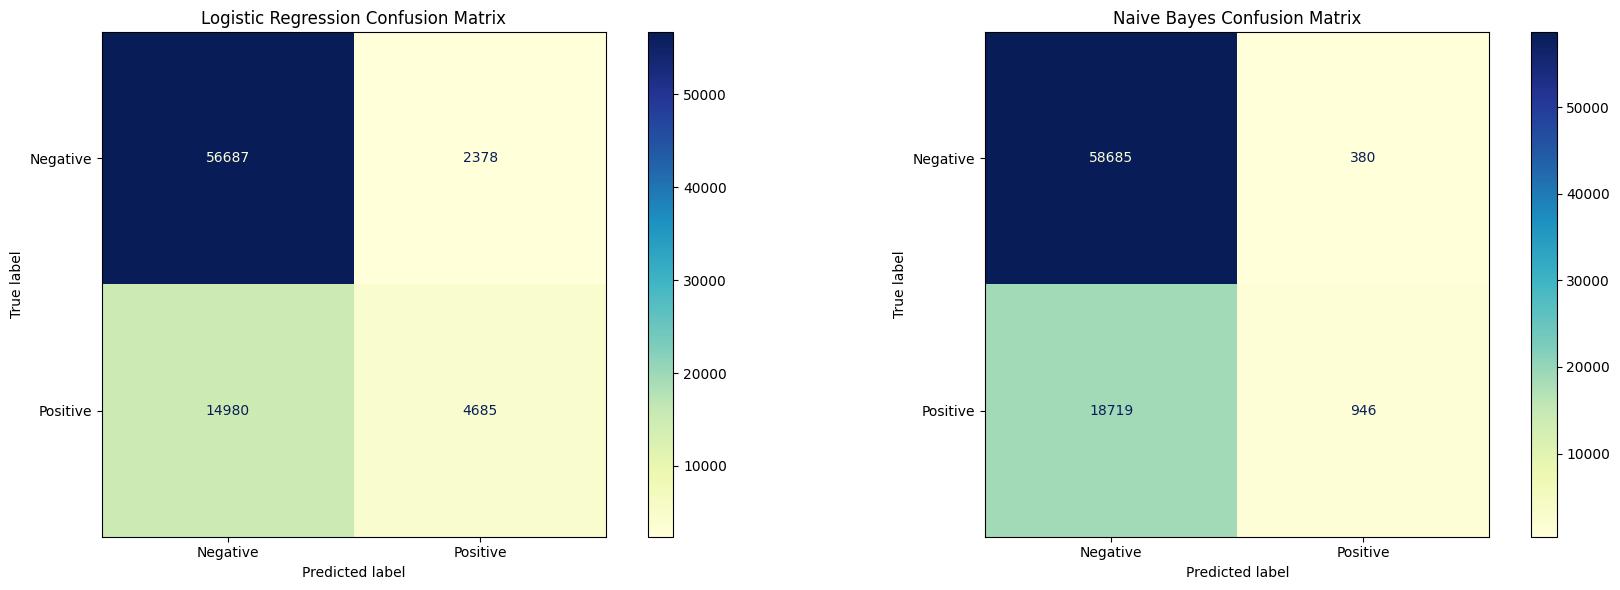

In [27]:
# confusion matrix comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_best_lr, labels=best_lr.classes_)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Negative', 'Positive'])
disp_lr.plot(ax=ax1, cmap="YlGnBu")
ax1.set_title('Logistic Regression Confusion Matrix')

# Naive Bayes Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_best_nb, labels=best_nb.classes_)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Negative', 'Positive'])
disp_nb.plot(ax=ax2, cmap="YlGnBu")
ax2.set_title('Naive Bayes Confusion Matrix')

plt.tight_layout()
plt.show()


# Final model
After comparison it's clear that the Logistic Regression model is the best model


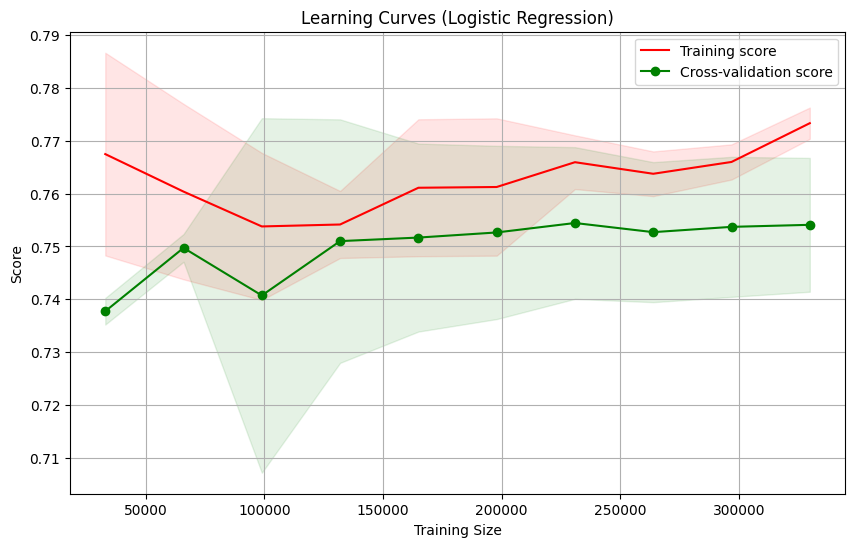

In [28]:
# Plotting performance of best model
train_sizes, train_scores, test_scores = learning_curve(
    best_lr,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    n_jobs=-1
)

# Calculate mean and std deviation of training and test scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, color='r', label='Training score')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Cross-validation score')

# Plot the standard deviation as shaded regions indicating the spread
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

plt.title('Learning Curves (Logistic Regression)')
plt.xlabel('Training Size')
plt.ylabel('Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()


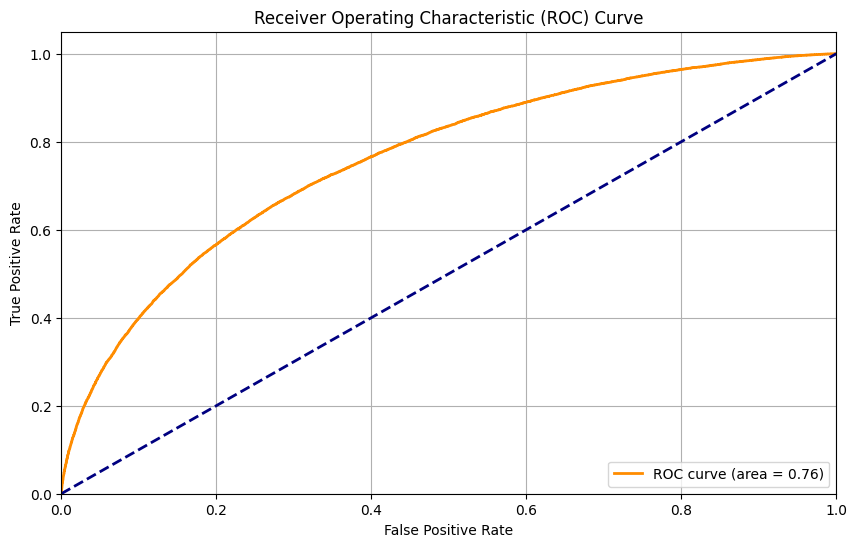

In [29]:
y_prob = best_lr.predict_proba(X_test)[:, 1]

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label=1)

# Calculate the AUC
roc_auc = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
